<a href="https://colab.research.google.com/github/DharaCS23181/Skincare_Product_Prediction/blob/main/LIGHTGBM(80_20).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 58
[LightGBM] [Info] Number of data points in the train set: 979, number of used features: 29
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi
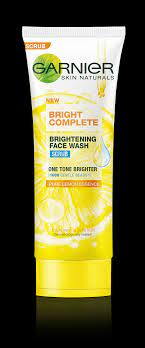

In [1]:
# ==============================
# 1. MOUNT GOOGLE DRIVE
# ==============================

from google.colab import drive
drive.mount('/content/drive')


# ==============================
# 2. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import re

from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score

from lightgbm import LGBMClassifier


# ==============================
# 3. LOAD DATASET
# ==============================

df = pd.read_csv("/content/drive/MyDrive/ML/skin_recommendation_dataset.csv")

data = df[['skintype','skin_condition','notable_effects','product_type']].copy()


# ==============================
# 4. CLEAN FUNCTION
# ==============================

def clean_text(x):
    x = str(x)
    x = re.sub(r"[^a-zA-Z0-9,\-\s]", "", x)
    return [i.strip().lower() for i in x.split(",") if i.strip() != ""]


# apply cleaning
data['skintype'] = data['skintype'].apply(clean_text)
data['skin_condition'] = data['skin_condition'].apply(clean_text)
data['notable_effects'] = data['notable_effects'].apply(clean_text)


# ==============================
# 5. ENCODING
# ==============================

mlb_skin = MultiLabelBinarizer()
mlb_condition = MultiLabelBinarizer()
mlb_effects = MultiLabelBinarizer()

skin_features = pd.DataFrame(
    mlb_skin.fit_transform(data['skintype']),
    columns=mlb_skin.classes_
)

condition_features = pd.DataFrame(
    mlb_condition.fit_transform(data['skin_condition']),
    columns=mlb_condition.classes_
)

effects_features = pd.DataFrame(
    mlb_effects.fit_transform(data['notable_effects']),
    columns=mlb_effects.classes_
)

X = pd.concat([skin_features, condition_features, effects_features], axis=1)

le = LabelEncoder()
y = le.fit_transform(data['product_type'])


# ==============================
# 6. TRAIN TEST SPLIT (70-30)
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# ==============================
# 7. TRAIN LIGHTGBM MODEL
# ==============================

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=50,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight='balanced',
    random_state=42
)

lgbm.fit(X_train, y_train)


# ==============================
# 8. EVALUATION
# ==============================

y_pred = lgbm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test, y_pred))


# ==============================
# 9. USER INPUT (NUMBER BASED)
# ==============================

print("\nSelect Skin Type:")
for i, val in enumerate(mlb_skin.classes_):
    print(i, ":", val)

skin_choice = int(input("Enter number: "))
user_skin = [mlb_skin.classes_[skin_choice]]


print("\nSelect Skin Condition:")
for i, val in enumerate(mlb_condition.classes_):
    print(i, ":", val)

cond_choice = int(input("Enter number: "))
user_condition = [mlb_condition.classes_[cond_choice]]


print("\nSelect Effect:")
for i, val in enumerate(mlb_effects.classes_):
    print(i, ":", val)

effect_choice = int(input("Enter number: "))
user_effect = [mlb_effects.classes_[effect_choice]]


# ==============================
# 10. CREATE INPUT
# ==============================

user_df = pd.DataFrame(columns=X.columns)
user_df.loc[0] = 0

for val in user_skin + user_condition + user_effect:
    if val in user_df.columns:
        user_df.loc[0, val] = 1


# ==============================
# 11. PREDICTION
# ==============================

prediction = lgbm.predict(user_df)
predicted_type = le.inverse_transform(prediction)

print("\n✅ Predicted Product Type:", predicted_type[0])


# ==============================
# 12. SMART RECOMMENDATION SYSTEM
# ==============================

filtered = df[df['product_type'] == predicted_type[0]].copy()

filtered['notable_effects'] = filtered['notable_effects'].astype(str).str.lower()
filtered['skin_condition'] = filtered['skin_condition'].astype(str).str.lower()
filtered['skintype'] = filtered['skintype'].astype(str).str.lower()


def calculate_score(row):
    score = 0

    if user_effect[0] in row['notable_effects']:
        score += 3

    if user_condition[0] in row['skin_condition']:
        score += 2

    if user_skin[0] in row['skintype']:
        score += 1

    return score


filtered['score'] = filtered.apply(calculate_score, axis=1)
filtered = filtered.sort_values(by='score', ascending=False)


# ==============================
# 13. TOP 3 RESULTS
# ==============================

print("\n🔥 Top Recommended Products:\n")

top_results = filtered.head(3)

for i, row in top_results.iterrows():
    print("🔹 Product Name:", row['product_name'])
    print("🔹 Brand:", row['brand'])
    print("🔹 Effects:", ", ".join(clean_text(row['notable_effects'])))
    print("🔹 Score:", row['score'])
    print("🔹 Image URL:", row['picture_src'])
    print("-"*40)